In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error


In [61]:
boston_housing = pd.read_csv("BostonHousing.csv")
boston_housing.head()
boston_housing.shape
boston_housing.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [62]:
X = boston_housing.drop("medv", axis=1)
y = boston_housing["medv"]

In [63]:
alphas = [0.01, 0.1, 1, 10, 100]


In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=19
)

In [65]:
scaler = StandardScaler()

In [66]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [73]:
train_errors = []
test_errors = []
coefficients = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)

    train_predictions = ridge.predict(X_train_scaled)
    test_predictions = ridge.predict(X_test_scaled)

    train_errors.append(train_errors)
    test_errors.append(test_errors)
    coefficients.append(ridge.coef_)

    print("Alpha:", alpha)
    print("Train MSE:", train_errors)
    print("Test MSE:", test_errors)
    print()


Alpha: 0.01
Train MSE: [[...]]
Test MSE: [[...]]

Alpha: 0.1
Train MSE: [[...], [...]]
Test MSE: [[...], [...]]

Alpha: 1
Train MSE: [[...], [...], [...]]
Test MSE: [[...], [...], [...]]

Alpha: 10
Train MSE: [[...], [...], [...], [...]]
Test MSE: [[...], [...], [...], [...]]

Alpha: 100
Train MSE: [[...], [...], [...], [...], [...]]
Test MSE: [[...], [...], [...], [...], [...]]



In [75]:
results = pd.DataFrame({
    "Alpha": alphas,
    "Train MSE": train_errors,
    "Test MSE": test_errors
})

results

,Alpha,Train MSE,Test MSE
0,0.01,"[[[[[...], [...], [...], [...], [...]], [[...]...","[[[[[...], [...], [...], [...], [...]], [[...]..."
1,0.10,"[[[[[...], [...], [...], [...], [...]], [[...]...","[[[[[...], [...], [...], [...], [...]], [[...]..."
2,1.00,"[[[[[...], [...], [...], [...], [...]], [[...]...","[[[[[...], [...], [...], [...], [...]], [[...]..."
3,10.00,"[[[[[...], [...], [...], [...], [...]], [[...]...","[[[[[...], [...], [...], [...], [...]], [[...]..."
4,100.00,"[[[[[...], [...], [...], [...], [...]], [[...]...","[[[[[...], [...], [...], [...], [...]], [[...]..."


In [76]:
coeficients = np.array(coefficients)

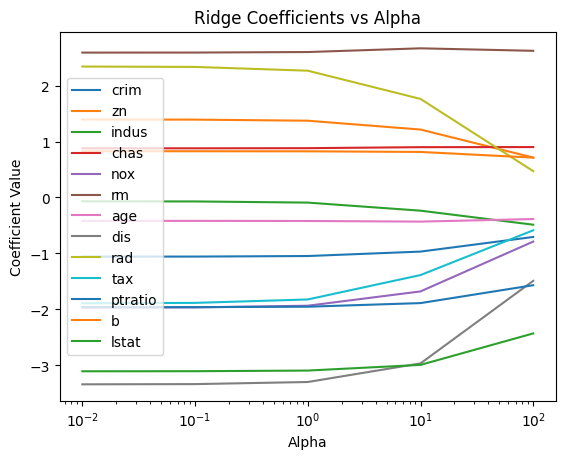

In [77]:
for i, feature in enumerate(X.columns):
    plt.plot(alphas, coeficients[:, i], label=feature)

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficient Value")
plt.title("Ridge Coefficients vs Alpha")
plt.legend()
plt.show()

**Conclusion**

When the model's predictions as α (Alpha) increases, the regularisation becomes too stronger. The model relies less heavily on individual features but would become less flexible as well. If Alpha becomes a bit too large, the model itself may underfit.

The cofficient doesnt disappear but rather shrinks to zero while the alpha increases.

The Ridge does not eliminate the features as the Ridge uses L2 regularisation, which would reduce coefficient magnitudes but that does not force them down to zero exactly. The features simply remains in the model.